<a href="https://colab.research.google.com/github/KP-365/Fake_news/blob/main/eval_FakeNews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Set up Colab and clone the repository

This clones the project when needed, removes Colab's incompatible `torchao`, and installs the pinned dependencies. Package-install output should finish without an error before you continue.

In [13]:
import os
from pathlib import Path

if not Path("predict.py").exists():
    !git clone https://github.com/KP-365/Fake_news
    os.chdir("Fake_news")

!python3 -m pip uninstall -y torchao
!python3 -m pip install -q -r requirements.txt

## 2. Load the trained checkpoint

This loads the tokenizer, RoBERTa-LoRA adapter, and classifier head once for the rest of the notebook. The output shows whether inference will run on CPU or GPU.

In [14]:
from predict import ID_TO_LABEL, MAX_LENGTH, load_model

model, tokenizer, device = load_model()
print(f"Checkpoint loaded on {device}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Checkpoint loaded on cuda


## 3. Rebuild the held-out test split

This repeats the training notebook's cleaning and stratified 70/15/15 split with seed 42, so the test articles do not leak into training. The output shows the test-set size and class balance.

In [15]:
import os
import re

import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split

dataset_path = kagglehub.dataset_download(
    "saurabhshahane/fake-news-classification"
)
welfake_df = pd.read_csv(os.path.join(dataset_path, "WELFake_Dataset.csv"))

if "Unnamed: 0" in welfake_df.columns:
    welfake_df = welfake_df.drop(columns=["Unnamed: 0"])

welfake_df["title"] = welfake_df["title"].fillna("")
welfake_df = welfake_df.dropna(subset=["text"])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    return re.sub(r"\s+", " ", text).strip()

welfake_df["title"] = welfake_df["title"].apply(clean_text)
welfake_df["text"] = welfake_df["text"].apply(clean_text)
welfake_df = welfake_df[welfake_df["text"].str.len() > 0]
welfake_df["content"] = (
    welfake_df["title"] + ". " + welfake_df["text"]
).str.strip(". ")
welfake_df = welfake_df.drop_duplicates(subset=["text"])

train_df, temp_df = train_test_split(
    welfake_df,
    test_size=0.3,
    stratify=welfake_df["label"],
    random_state=42,
)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42,
)

print(f"Held-out test examples: {len(test_df):,}")
print(test_df["label"].value_counts().sort_index())

Using Colab cache for faster access to the 'fake-news-classification' dataset.
Held-out test examples: 9,398
label
0    5193
1    4205
Name: count, dtype: int64


## 4. Evaluate the full test set

This runs batched inference over every held-out article. Accuracy is the overall correct share; macro-F1 weights real and fake equally; per-class precision and recall show false-alarm and missed-case behaviour; the confusion matrix uses true labels as rows and predictions as columns.

### How to read the results

These 9,398 test articles were never shown to the model during training. About 40 total errors means the off-diagonal confusion-matrix cells should sum to roughly 40.

Accuracy: 0.9957
Macro F1: 0.9957
Per-class precision and recall:
              precision    recall  f1-score   support

        real     0.9952    0.9971    0.9962      5193
        fake     0.9964    0.9941    0.9952      4205

    accuracy                         0.9957      9398
   macro avg     0.9958    0.9956    0.9957      9398
weighted avg     0.9957    0.9957    0.9957      9398

Confusion matrix:
[[5178   15]
 [  25 4180]]


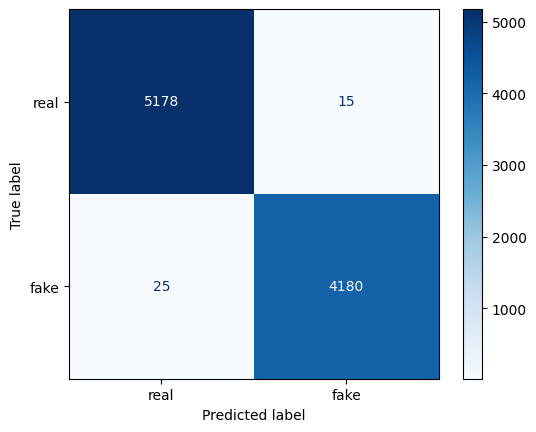

In [16]:
import numpy as np
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

batch_size = 32
test_texts = test_df["content"].tolist()
true_labels = test_df["label"].to_numpy()
predicted_labels = []
prediction_confidences = []

model.eval()
for start in range(0, len(test_texts), batch_size):
    batch_texts = test_texts[start:start + batch_size]
    encoded = tokenizer(
        batch_texts,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        return_tensors="pt",
    )
    encoded = {name: tensor.to(device) for name, tensor in encoded.items()}

    with torch.no_grad():
        probabilities = torch.softmax(model(**encoded).logits, dim=-1)

    confidences, predictions = probabilities.max(dim=-1)
    predicted_labels.extend(predictions.cpu().tolist())
    prediction_confidences.extend(confidences.cpu().tolist())

predicted_labels = np.asarray(predicted_labels)
prediction_confidences = np.asarray(prediction_confidences)
label_ids = sorted(ID_TO_LABEL)
target_names = [ID_TO_LABEL[label_id] for label_id in label_ids]
accuracy = accuracy_score(true_labels, predicted_labels)
macro_f1 = f1_score(true_labels, predicted_labels, average="macro")
report = classification_report(
    true_labels,
    predicted_labels,
    labels=label_ids,
    target_names=target_names,
    digits=4,
)
matrix = confusion_matrix(true_labels, predicted_labels, labels=label_ids)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print("Per-class precision and recall:")
print(report)
print("Confusion matrix:")
print(matrix)
ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=target_names,
).plot(cmap="Blues")

## 5. Compare against simple baselines

Baselines show whether the trained transformer adds value beyond common word-frequency patterns. The **Majority-class baseline** always predicts the most common training label. The table compares accuracy and macro-F1 on the same held-out test set; the chart makes the macro-F1 gap easy to see.

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
train_tfidf = tfidf.fit_transform(train_df["content"])
test_tfidf = tfidf.transform(test_df["content"])

logistic_baseline = LogisticRegression(
    max_iter=1000, random_state=42, solver="liblinear"
)
logistic_baseline.fit(train_tfidf, train_df["label"])
logistic_predictions = logistic_baseline.predict(test_tfidf)

dummy_baseline = DummyClassifier(strategy="most_frequent")
dummy_baseline.fit(train_tfidf, train_df["label"])
dummy_predictions = dummy_baseline.predict(test_tfidf)

comparison = pd.DataFrame([
    {"Model": "RoBERTa-LoRA", "Accuracy": accuracy, "Macro F1": macro_f1},
    {
        "Model": "TF-IDF + Logistic Regression",
        "Accuracy": accuracy_score(true_labels, logistic_predictions),
        "Macro F1": f1_score(true_labels, logistic_predictions, average="macro"),
    },
    {
        "Model": "Majority-class baseline",
        "Accuracy": accuracy_score(true_labels, dummy_predictions),
        "Macro F1": f1_score(true_labels, dummy_predictions, average="macro"),
    },
])
display(comparison.style.format({"Accuracy": "{:.4f}", "Macro F1": "{:.4f}"}))

ax = comparison.plot.bar(
    x="Model", y="Macro F1", ylim=(0, 1), legend=False, color="steelblue"
)
ax.set_ylabel("Macro F1")
ax.set_title("Held-out WELFake test-set comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 6. Inspect 10 random simulation articles

This selects 10 reproducible random test articles with seed 42. Compare each true label with the predicted label and confidence to spot-check individual behaviour.

In [17]:
sample_rng = np.random.default_rng(42)
sample_positions = sample_rng.choice(len(test_df), size=10, replace=False)
sample_predictions = test_df.iloc[sample_positions][["title", "label"]].copy()
sample_predictions["true_label"] = [
    ID_TO_LABEL[label] for label in sample_predictions["label"]
]
sample_predictions["predicted_label"] = [
    ID_TO_LABEL[label] for label in predicted_labels[sample_positions]
]
sample_predictions["confidence"] = prediction_confidences[sample_positions]
sample_predictions.drop(columns=["label"]).reset_index(drop=True)

,title,true_label,predicted_label,confidence
0,'Rain begins with a single drop:' Saudi women ...,real,real,0.998421
1,Rohingya who says she was raped in Myanmar hop...,real,real,0.998366
2,"U.S. Congress tangles with Facebook, other soc...",real,real,0.998448
3,Texas Republican Bringing Two Anti-LGBT Bathro...,fake,fake,0.998342
4,PULITZER PRIZE WINNING AUTHOR TONI MORRISON: “...,fake,fake,0.998245
5,Trump campaign's digital director to meet Hous...,real,real,0.998455
6,Common Core standardized tests begin Tuesday,real,real,0.981373
7,"‘Space Wars are Likely in the Future’ as US, R...",fake,fake,0.959454
8,SHOCKING AUDIO RELEASED Of John Kerry Discussi...,fake,fake,0.998327
9,Apparently Trump’s Administration Hasn’t Heard...,fake,fake,0.998428
